# HAE hierarchical reconstruction manual eval

手动选择两层 HAE 的 checkpoint、样本和变量，比较：

- `top_only`: 只用 top latent 解码，bottom latent 置空
- `top+bottom`: 同时使用 top latent 和 bottom latent 解码
- `dc_ae`: 非分层 AE/DC-AE baseline；默认使用 `AE_KL_hybrid_1024_16_full/best.pth`

误差同时给出 normalized L1/MSE/Bias、训练日志同口径的 denormalized 分变量 L1/Bias，以及常看变量的单通道误差/Bias。



In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path("/mnt/petrelfs/fanhang/HAE")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.config import load_config
from utils.builder import ConfigBuilder
from trainers.ae_kl_trainer import STD_LAYER

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
print("device:", DEVICE)
print("root:", ROOT)


/mnt/petrelfs/fanhang/miniforge3/envs/LDA/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/petrelfs/fanhang/miniforge3/envs/LDA/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


device: cuda:0
root: /mnt/petrelfs/fanhang/HAE


In [2]:
# ===== 手动改这里 =====

RUN_DIR = ROOT / "output" / "AE_KL_hybrid_hier2_34_full"
CONFIG_PATH = ROOT / "configs" / "ae_kl_hybrid_hier2_34_full.yaml"
CHECKPOINT_PATH = RUN_DIR / "best.pth"

# DC-AE / non-hierarchical AE baseline。
# 这里按你的说明，使用 AE_KL_hybrid_1024_16_full/best.pth。
# 这个模型不是两层 HAE；notebook 会把它作为 dc_ae 行/列参与对比。
REQUIRE_DCAE = True  # 这个默认 checkpoint 应该存在；不存在就直接报错。
DCAE_RUN_DIR = ROOT / "output" / "AE_KL_hybrid_1024_16_full"
DCAE_CONFIG_PATH = DCAE_RUN_DIR / "config_resolved.yaml"
DCAE_CHECKPOINT_PATH = DCAE_RUN_DIR / "best.pth"

# 如果后面要切回 EfficientViT patch-stem config，可以手动改成：
# DCAE_RUN_DIR = ROOT / "output" / "AE_578_16_evit_ae20"
# DCAE_CONFIG_PATH = ROOT / "configs" / "ae_kl_578_16_evit_ae20.yaml"
# DCAE_CHECKPOINT_PATH = DCAE_RUN_DIR / "best.pth"

SPLIT = "valid"      # valid / test / train
SAMPLE_INDEX = 0      # 手动选择 case
CHANNEL_NAME = "z_500"

print("HAE config:", CONFIG_PATH)
print("HAE checkpoint:", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("DC-AE config:", DCAE_CONFIG_PATH)
print("DC-AE checkpoint:", DCAE_CHECKPOINT_PATH, DCAE_CHECKPOINT_PATH.exists())



HAE config: /mnt/petrelfs/fanhang/HAE/configs/ae_kl_hybrid_hier2_34_full.yaml
HAE checkpoint: /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_hier2_34_full/best.pth True
DC-AE config: /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_1024_16_full/config_resolved.yaml
DC-AE checkpoint: /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_1024_16_full/best.pth True


In [3]:
SINGLE_LEVEL_NAMES = ["msl", "u10", "v10", "t2m"]
HEIGHT_LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
MULTI_LEVEL_NAMES = ["z", "q", "u", "v", "t"]
CHANNEL_NAMES = SINGLE_LEVEL_NAMES + [f"{v}_{h}" for v in MULTI_LEVEL_NAMES for h in HEIGHT_LEVELS]
CHANNEL_TO_INDEX = {name: i for i, name in enumerate(CHANNEL_NAMES)}

GROUP_SLICES = {
    "z": slice(4, 17),
    "q": slice(17, 30),
    "u": slice(30, 43),
    "v": slice(43, 56),
    "t": slice(56, 69),
}

SELECTED_CHANNELS = ["z_500", "t_850", "u_850", "v_850", "t2m", "msl"]

assert CHANNEL_TO_INDEX["z_500"] == 11
print("num channels:", len(CHANNEL_NAMES), "z_500 index:", CHANNEL_TO_INDEX["z_500"])


num channels: 69 z_500 index: 11


In [4]:
def _strip_module_prefix(state_dict):
    if not any(k.startswith("module.") for k in state_dict):
        return state_dict
    return {k[len("module."):]: v for k, v in state_dict.items()}


def load_model(config_path, checkpoint_path, device, label="model"):
    cfg = load_config(str(config_path))
    builder = ConfigBuilder(cfg)
    model = builder.build_model().to(device).eval()

    ckpt = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(ckpt, dict):
        state = ckpt.get("MODEL_STATE") or ckpt.get("MODEL") or ckpt.get("model") or ckpt.get("state_dict") or ckpt
    else:
        state = ckpt
    state = _strip_module_prefix(state)
    missing, unexpected = model.load_state_dict(state, strict=False)

    print(f"loaded {label}:", type(model).__name__)
    print("missing keys:", len(missing), "unexpected keys:", len(unexpected))
    if missing[:5]:
        print("missing first keys:", missing[:5])
    if unexpected[:5]:
        print("unexpected first keys:", unexpected[:5])
    return cfg, builder, model


cfg, builder, model = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE, label="HAE")

model_status = [
    {
        "case": "hae_top_only / hae_top+bottom",
        "config": str(CONFIG_PATH),
        "checkpoint": str(CHECKPOINT_PATH),
        "checkpoint_exists": CHECKPOINT_PATH.exists(),
        "loaded": True,
        "note": "same HAE model, decoded with/without bottom latent",
    }
]

dcae_cfg = None
dcae_builder = None
dcae_model = None
if DCAE_CHECKPOINT_PATH.exists():
    dcae_cfg, dcae_builder, dcae_model = load_model(DCAE_CONFIG_PATH, DCAE_CHECKPOINT_PATH, DEVICE, label="DC-AE")
    model_status.append({
        "case": "dc_ae",
        "config": str(DCAE_CONFIG_PATH),
        "checkpoint": str(DCAE_CHECKPOINT_PATH),
        "checkpoint_exists": True,
        "loaded": True,
        "note": "non-hierarchical AE/DC-AE baseline",
    })
else:
    msg = f"DC-AE checkpoint not found: {DCAE_CHECKPOINT_PATH}"
    print("skip DC-AE:", msg)
    model_status.append({
        "case": "dc_ae",
        "config": str(DCAE_CONFIG_PATH),
        "checkpoint": str(DCAE_CHECKPOINT_PATH),
        "checkpoint_exists": False,
        "loaded": False,
        "note": msg,
    })
    if REQUIRE_DCAE:
        raise FileNotFoundError(msg)

model_status_df = pd.DataFrame(model_status)
print(model_status_df.to_string(index=False))

dataset = builder.build_dataset(SPLIT)
print("dataset length:", len(dataset))



/tmp/ipykernel_157993/3362792033.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location="cpu")


loaded HAE: HybridHier2VAEformer
missing keys: 1 unexpected keys: 0
missing first keys: ['bottom_fuse_scale']
loaded DC-AE: HybridVAEformer
missing keys: 0 unexpected keys: 0
                         case                                                                          config                                                           checkpoint  checkpoint_exists  loaded                                               note
hae_top_only / hae_top+bottom               /mnt/petrelfs/fanhang/HAE/configs/ae_kl_hybrid_hier2_34_full.yaml /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_hier2_34_full/best.pth               True    True same HAE model, decoded with/without bottom latent
                        dc_ae /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_1024_16_full/config_resolved.yaml  /mnt/petrelfs/fanhang/HAE/output/AE_KL_hybrid_1024_16_full/best.pth               True    True                 non-hierarchical AE/DC-AE baseline
dataset length: 1251


In [5]:
def to_batch(sample, device):
    if isinstance(sample, (tuple, list)):
        sample = sample[0]
    if isinstance(sample, np.ndarray):
        sample = torch.from_numpy(sample)
    sample = sample.float()
    if sample.ndim == 3:
        sample = sample.unsqueeze(0)
    return sample.to(device, non_blocking=True)


def posterior_mode(posterior):
    return posterior.mode() if hasattr(posterior, "mode") else posterior


x = to_batch(dataset[SAMPLE_INDEX], DEVICE)
print("x shape:", tuple(x.shape), "min/max:", float(x.min()), float(x.max()))

with torch.no_grad():
    posteriors = model.encode(x)
    z_top = posterior_mode(posteriors["top"])
    z_bottom = posterior_mode(posteriors["bottom"])
    recon_top = model.decode(z_top, None)
    recon_full = model.decode(z_top, z_bottom)

    recon_dcae = None
    z_dcae = None
    if dcae_model is not None:
        dcae_posterior = dcae_model.encode(x)
        z_dcae = posterior_mode(dcae_posterior)
        recon_dcae = dcae_model.decode(z_dcae)

print("z_top:", tuple(z_top.shape), "elements/sample:", int(np.prod(z_top.shape[1:])))
print("z_bottom:", tuple(z_bottom.shape), "elements/sample:", int(np.prod(z_bottom.shape[1:])))
print("HAE latent total:", int(np.prod(z_top.shape[1:]) + np.prod(z_bottom.shape[1:])))
if z_dcae is not None:
    print("z_dcae:", tuple(z_dcae.shape), "elements/sample:", int(np.prod(z_dcae.shape[1:])))
print("recon_top:", tuple(recon_top.shape), "recon_full:", tuple(recon_full.shape))
if recon_dcae is not None:
    print("recon_dcae:", tuple(recon_dcae.shape))


x shape: (1, 69, 128, 256) min/max: -5.154877662658691 5.891878604888916
z_top: (1, 34, 8, 16) elements/sample: 4352
z_bottom: (1, 34, 32, 64) elements/sample: 69632
HAE latent total: 73984
z_dcae: (1, 552, 16, 32) elements/sample: 282624
recon_top: (1, 69, 128, 256) recon_full: (1, 69, 128, 256)
recon_dcae: (1, 69, 128, 256)


In [6]:
STD = torch.tensor(STD_LAYER, dtype=torch.float32, device=DEVICE).view(1, -1, 1, 1)


def denorm(t):
    # 和 trainer validate 一致：这里只乘 std，不加 mean。
    return t * STD


def reconstruction_metrics(pred, target, name):
    pred_d = denorm(pred)
    target_d = denorm(target)
    diff = pred - target
    diff_d = pred_d - target_d
    row = {
        "case": name,
        "norm_l1": float(F.l1_loss(pred, target).item()),
        "norm_mse": float(F.mse_loss(pred, target).item()),
        "norm_bias": float(diff.mean().item()),
        "denorm_l1_all": float(F.l1_loss(pred_d, target_d).item()),
        "denorm_bias_all": float(diff_d.mean().item()),
    }
    for group_name, sl in GROUP_SLICES.items():
        row[f"{group_name}_err"] = float(F.l1_loss(pred_d[:, sl], target_d[:, sl]).item())
        row[f"{group_name}_bias"] = float(diff_d[:, sl].mean().item())
    for ch_name in SELECTED_CHANNELS:
        ch = CHANNEL_TO_INDEX[ch_name]
        row[f"{ch_name}_mae"] = float(F.l1_loss(pred_d[:, ch], target_d[:, ch]).item())
        row[f"{ch_name}_bias"] = float(diff_d[:, ch].mean().item())
    return row


metric_rows = [
    reconstruction_metrics(recon_top, x, "hae_top_only"),
    reconstruction_metrics(recon_full, x, "hae_top+bottom"),
]
if recon_dcae is not None:
    metric_rows.append(reconstruction_metrics(recon_dcae, x, "dc_ae"))
metrics_df = pd.DataFrame(metric_rows)
metrics_df


,case,norm_l1,norm_mse,norm_bias,denorm_l1_all,denorm_bias_all,z_err,z_bias,q_err,q_bias,...,t_850_mae,t_850_bias,u_850_mae,u_850_bias,v_850_mae,v_850_bias,t2m_mae,t2m_bias,msl_mae,msl_bias
0,hae_top_only,0.140094,0.051010,-0.014039,36.468979,-23.141994,181.011749,-121.285446,0.000275,-8.494402e-05,...,1.356003,-0.149982,1.616360,-0.636400,1.417143,-0.219361,94.911575,-22.430243,0.368217,-0.176552
1,hae_top+bottom,0.075062,0.015704,0.001856,11.044080,3.860151,51.037468,20.649603,0.000159,2.214235e-05,...,0.760805,-0.119525,0.961830,0.170515,0.835583,0.013771,60.725929,-0.278975,0.208495,0.089011
2,dc_ae,0.044137,0.005523,-0.000134,5.735507,-0.002840,25.451624,-0.038613,0.000102,-1.259937e-07,...,0.558679,-0.002938,0.562117,-0.002083,0.468332,-0.001359,42.102776,0.336048,0.114770,-0.003566


In [7]:
# Compact MAE/Bias view for all loaded cases.
# Bias is signed mean error: prediction - truth.
mae_bias_rows = []
for _, row in metrics_df.iterrows():
    case = row["case"]
    mae_bias_rows.append({
        "case": case,
        "scope": "all",
        "name": "all_channels",
        "mae": row.get("denorm_l1_all", np.nan),
        "bias": row.get("denorm_bias_all", np.nan),
    })
    for group_name in GROUP_SLICES:
        mae_bias_rows.append({
            "case": case,
            "scope": "group",
            "name": group_name,
            "mae": row.get(f"{group_name}_err", np.nan),
            "bias": row.get(f"{group_name}_bias", np.nan),
        })
    for ch_name in SELECTED_CHANNELS:
        mae_bias_rows.append({
            "case": case,
            "scope": "channel",
            "name": ch_name,
            "mae": row.get(f"{ch_name}_mae", np.nan),
            "bias": row.get(f"{ch_name}_bias", np.nan),
        })

mae_bias_df = pd.DataFrame(mae_bias_rows)
if "dc_ae" not in set(metrics_df["case"]):
    print("dc_ae metrics are absent because DC-AE checkpoint was not loaded. Check model_status_df / DCAE_CHECKPOINT_PATH.")
mae_bias_df


,case,scope,name,mae,bias
0,hae_top_only,all,all_channels,36.468979,-2.314199e+01
1,hae_top_only,group,z,181.011749,-1.212854e+02
2,hae_top_only,group,q,0.000275,-8.494402e-05
3,hae_top_only,group,u,1.960186,3.159207e-01
4,hae_top_only,group,v,1.838352,1.876612e-01
5,hae_top_only,group,t,1.026407,-2.636238e-01
6,hae_top_only,channel,z_500,192.130692,-1.320722e+02
7,hae_top_only,channel,t_850,1.356003,-1.499822e-01
8,hae_top_only,channel,u_850,1.616360,-6.364003e-01
9,hae_top_only,channel,v_850,1.417143,-2.193614e-01


In [8]:
compare = metrics_df.set_index("case")
if {"hae_top_only", "hae_top+bottom"}.issubset(compare.index):
    improve = (compare.loc["hae_top_only"] - compare.loc["hae_top+bottom"]) / compare.loc["hae_top_only"].replace(0, np.nan)
    improve = improve.to_frame("relative_improvement_hae_full_vs_top_only")
else:
    improve = pd.DataFrame()
improve


,relative_improvement_hae_full_vs_top_only
norm_l1,0.464204
norm_mse,0.692142
norm_bias,1.132226
denorm_l1_all,0.697165
denorm_bias_all,1.166803
z_err,0.718043
z_bias,1.170256
q_err,0.420670
q_bias,1.260670
u_err,0.431036


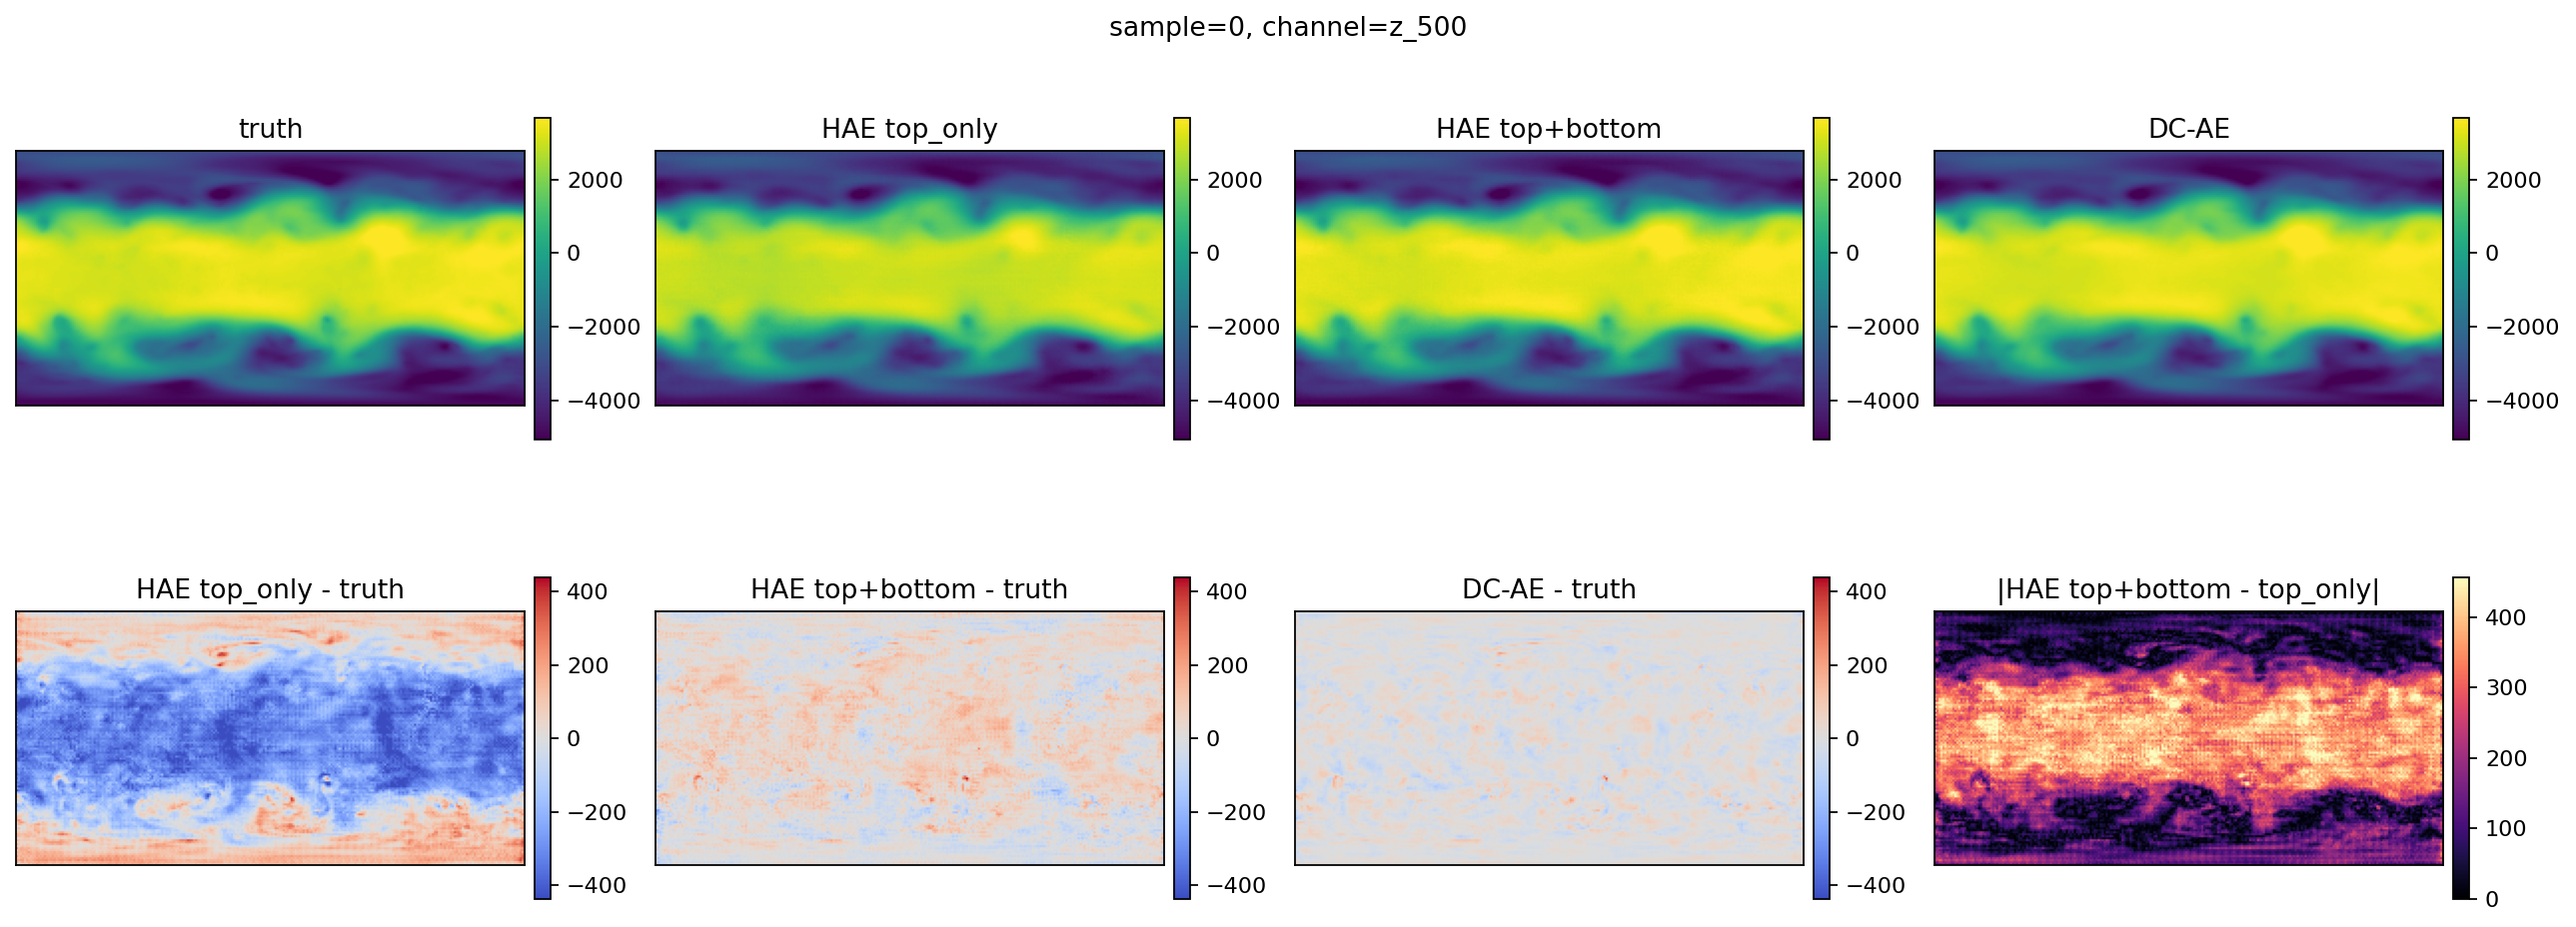

In [9]:
def plot_channel(channel_name=CHANNEL_NAME):
    ch = CHANNEL_TO_INDEX[channel_name]
    truth = denorm(x)[0, ch].detach().cpu().numpy()
    top = denorm(recon_top)[0, ch].detach().cpu().numpy()
    full = denorm(recon_full)[0, ch].detach().cpu().numpy()
    dcae = denorm(recon_dcae)[0, ch].detach().cpu().numpy() if recon_dcae is not None else None

    # Keep prediction-minus-truth signed. Only the top+bottom vs top-only delta is absolute.
    err_top = top - truth
    err_full = full - truth
    err_dcae = dcae - truth if dcae is not None else None
    delta_abs = np.abs(full - top)

    vmin, vmax = np.percentile(truth, [1, 99])
    signed_errors = [err_top, err_full] + ([err_dcae] if err_dcae is not None else [])
    err_abs = max(
        max(abs(np.percentile(e, 1)), abs(np.percentile(e, 99))) for e in signed_errors
    )
    err_abs = max(err_abs, 1e-12)
    delta_vmax = max(np.percentile(delta_abs, 99), 1e-12)

    if dcae is not None:
        fig, axs = plt.subplots(2, 4, figsize=(16, 6), dpi=160, constrained_layout=True)
        images = [
            (truth, "truth", "viridis", vmin, vmax),
            (top, "HAE top_only", "viridis", vmin, vmax),
            (full, "HAE top+bottom", "viridis", vmin, vmax),
            (dcae, "DC-AE", "viridis", vmin, vmax),
            (err_top, "HAE top_only - truth", "coolwarm", -err_abs, err_abs),
            (err_full, "HAE top+bottom - truth", "coolwarm", -err_abs, err_abs),
            (err_dcae, "DC-AE - truth", "coolwarm", -err_abs, err_abs),
            (delta_abs, "|HAE top+bottom - top_only|", "magma", 0, delta_vmax),
        ]
    else:
        fig, axs = plt.subplots(2, 3, figsize=(13, 6), dpi=160, constrained_layout=True)
        images = [
            (truth, "truth", "viridis", vmin, vmax),
            (top, "HAE top_only", "viridis", vmin, vmax),
            (full, "HAE top+bottom", "viridis", vmin, vmax),
            (err_top, "HAE top_only - truth", "coolwarm", -err_abs, err_abs),
            (err_full, "HAE top+bottom - truth", "coolwarm", -err_abs, err_abs),
            (delta_abs, "|HAE top+bottom - top_only|", "magma", 0, delta_vmax),
        ]

    for ax, (arr, title, cmap, lo, hi) in zip(axs.ravel(), images):
        im = ax.imshow(arr, cmap=cmap, vmin=lo, vmax=hi, origin="lower")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.032, pad=0.02, shrink=0.72)
    fig.suptitle(f"sample={SAMPLE_INDEX}, channel={channel_name}")
    return fig

plot_channel(CHANNEL_NAME);


In [10]:
# 可选：快速扫多个样本，查看 HAE top_only、HAE top+bottom 和 DC-AE 的平均误差/Bias。
NUM_SAMPLES = 8
START_INDEX = 0

rows = []
for idx in range(START_INDEX, START_INDEX + NUM_SAMPLES):
    x_i = to_batch(dataset[idx], DEVICE)
    with torch.no_grad():
        p_i = model.encode(x_i)
        zt_i = posterior_mode(p_i["top"])
        zb_i = posterior_mode(p_i["bottom"])
        top_i = model.decode(zt_i, None)
        full_i = model.decode(zt_i, zb_i)

        dcae_i = None
        if dcae_model is not None:
            dcae_p_i = dcae_model.encode(x_i)
            zd_i = posterior_mode(dcae_p_i)
            dcae_i = dcae_model.decode(zd_i)

    rows.append({"sample": idx, **reconstruction_metrics(top_i, x_i, "hae_top_only")})
    rows.append({"sample": idx, **reconstruction_metrics(full_i, x_i, "hae_top+bottom")})
    if dcae_i is not None:
        rows.append({"sample": idx, **reconstruction_metrics(dcae_i, x_i, "dc_ae")})

batch_df = pd.DataFrame(rows)
summary_df = batch_df.groupby("case").mean(numeric_only=True)
summary_df


,sample,norm_l1,norm_mse,norm_bias,denorm_l1_all,denorm_bias_all,z_err,z_bias,q_err,q_bias,...,t_850_mae,t_850_bias,u_850_mae,u_850_bias,v_850_mae,v_850_bias,t2m_mae,t2m_bias,msl_mae,msl_bias
case,,,,,,,,,,,,,,,,,,,,,
dc_ae,3.5,0.044113,0.005590,-0.000092,5.671729,-0.107487,25.129964,-0.582934,0.000102,1.525826e-07,...,0.559899,0.004700,0.558210,-0.001733,0.471159,-0.003367,41.862215,0.174734,0.114476,-0.005706
hae_top+bottom,3.5,0.075085,0.015786,0.002246,11.604200,4.618632,54.082627,24.449877,0.000159,2.267423e-05,...,0.764368,-0.076560,0.958249,0.176510,0.832995,0.027184,59.845375,2.502247,0.208413,0.091889
hae_top_only,3.5,0.139809,0.051253,-0.014403,35.824947,-22.508186,177.695066,-118.067274,0.000277,-9.061041e-05,...,1.332694,-0.136232,1.587626,-0.612075,1.373920,-0.207123,93.773878,-20.627972,0.360901,-0.177069


In [11]:
# Compact averaged MAE/Bias view from the multi-sample sweep.
summary_mae_bias_rows = []
for case, row in summary_df.iterrows():
    summary_mae_bias_rows.append({
        "case": case,
        "scope": "all",
        "name": "all_channels",
        "mae": row.get("denorm_l1_all", np.nan),
        "bias": row.get("denorm_bias_all", np.nan),
    })
    for group_name in GROUP_SLICES:
        summary_mae_bias_rows.append({
            "case": case,
            "scope": "group",
            "name": group_name,
            "mae": row.get(f"{group_name}_err", np.nan),
            "bias": row.get(f"{group_name}_bias", np.nan),
        })
    for ch_name in SELECTED_CHANNELS:
        summary_mae_bias_rows.append({
            "case": case,
            "scope": "channel",
            "name": ch_name,
            "mae": row.get(f"{ch_name}_mae", np.nan),
            "bias": row.get(f"{ch_name}_bias", np.nan),
        })

summary_mae_bias_df = pd.DataFrame(summary_mae_bias_rows)
if "dc_ae" not in set(summary_df.index):
    print("dc_ae averaged metrics are absent because DC-AE checkpoint was not loaded. Check model_status_df / DCAE_CHECKPOINT_PATH.")
summary_mae_bias_df


,case,scope,name,mae,bias
0,dc_ae,all,all_channels,5.671729,-1.074869e-01
1,dc_ae,group,z,25.129964,-5.829344e-01
2,dc_ae,group,q,0.000102,1.525826e-07
3,dc_ae,group,u,0.664331,1.700770e-04
4,dc_ae,group,v,0.575699,-1.404512e-03
5,dc_ae,group,t,0.393857,1.318369e-03
6,dc_ae,channel,z_500,22.392354,-1.390598e+00
7,dc_ae,channel,t_850,0.559899,4.699690e-03
8,dc_ae,channel,u_850,0.558210,-1.733481e-03
9,dc_ae,channel,v_850,0.471159,-3.367125e-03


In [12]:
# 如果要释放 notebook 里的 petrel worker / shared memory，最后执行这个单元。
try:
    dataset.close()
    print("dataset closed")
except Exception as exc:
    print("close skipped:", repr(exc))


dataset closed
